#Intro to Data Visualization

objetivo: visualizar datos para interpretar patrones, tendencias y anomalías.

* Línea: mostrar cambios a lo largo del tiempo.

* Barra: comparar cantidades entre categorías.

* Histograma: distribución de un conjunto continuo.

* Box Plot: mostrar medianas, cuartiles y outliers.

* Scatter: relación entre dos variables.

* Bubble: scatter con dimensión/es extra/s (hue - tamaño).

* Treemap: datos jerárquicos con proporciones (paiz > region > productos)

* Heatmap: magnitudes representadas por color.

* Word Cloud: frecuencia de palabras en texto.

##Data formating o formateo

Limpieza, homogeneización y conversión de tipos de datos.

lo + usual: eliminar NaN, convertir tipos (astype), pasar a minúsculas, eliminar espacios.

from a given pandas dataframe df:

* to eliminate all missing values : df.dropna(inplace=True).

* to check the data types : df.dtypes.

* convert a data type a to a data type b : df['column_name_a'] = df['column_name_a'].astype('b') ( for example : df['Tweet Location'] = df['Tweet Location'].astype('string')).

* to format all categorical data to lowercase : df['column_name'] = df['column_name'].str.lower().

* to remove all whitespace : df['column_name'] = df['column_name'].str.replace(' ', '').

* to remove leading whitespace in strings: df['column_name'] = df['column_name'].str.lstrip().

* to remove trailing whitespace in strings: df['column_name'] = df['column_name'].str.rstrip().

* to remove whitespace from both ends: df['column_name'] = df['column_name'].str.strip().

* to list all unique values in a column : df['column_name'].unique().

In [ ]:
import pandas as pd
import numpy as np

# Sample data
data = {
    'Country': ['USA', 'usa', 'Canada', 'CANADA'],  #upper and lower
    'City': ['New York', '   Los Angeles   ', '   Toronto   ', 'Vancouver'],  #with spaces
    'Population': [8419000, '3971000     ', ' 2930000', 675218],  #mith spaces and mix string/int
    'Date': ['2023-07-01', '07/04/2023', '2023-07-03', '2023-07-02'],  #mixed dates formats
    'Temperature': [25, 31, 28,21]
}

df = pd.DataFrame(data)
print(df)
print(df.dtypes)


  Country               City    Population        Date  Temperature
0     USA           New York       8419000  2023-07-01           25
1     usa     Los Angeles     3971000       07/04/2023           31
2  Canada         Toronto          2930000  2023-07-03           28
3  CANADA          Vancouver        675218  2023-07-02           21
Country        object
City           object
Population     object
Date           object
Temperature     int64
dtype: object


In [ ]:
df['Country'] = df['Country'].astype('string').str.lower()
df['City'] = df['City'].astype('string').str.lower()
df['Population'] = pd.to_numeric(df['Population'], errors='coerce').astype('int64')  #nullable integer
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce').astype('int64')  #nullable integer
# remove whitespace from both ends (compact form):
df['City'] = df['City'].str.strip()

print(df.dtypes)
df


Country        string[python]
City           string[python]
Population              int64
Date           datetime64[ns]
Temperature             int64
dtype: object


/tmp/ipython-input-228592437.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)


,Country,City,Population,Date,Temperature
0,usa,new york,8419000,2023-07-01,25
1,usa,los angeles,3971000,NaT,31
2,canada,toronto,2930000,2023-07-03,28
3,canada,vancouver,675218,2023-07-02,21


In [ ]:
#eliminate all missing values
df.dropna(inplace=True)  #elimina el registro 1, ojo tal vez te conviene y debes hacer el arreglo primero a mano

print(df['Country'].unique())
df

<StringArray>
['usa', 'canada']
Length: 2, dtype: string


,Country,City,Population,Date,Temperature
0,usa,new york,8419000,2023-07-01,25
2,canada,toronto,2930000,2023-07-03,28
3,canada,vancouver,675218,2023-07-02,21


##Indexación jerárquica:

Multiples niveles de índices para organizar y acceder fácilmente a datos complejos.

Ejemplo: índice tanto por Country como por City (diferentes niveles geograficos)

O en fechas --> año - mes - semana - dia

Ventaja: mejor organización, agrupamiento y filtrado eficiente.


In [ ]:
df.set_index(['Country',	'City',	'Date'], inplace=True)
canada_df = df.loc['canada']
canada_df


,,Population,Temperature
City,Date,,
toronto,2023-07-03,2930000,28
vancouver,2023-07-02,675218,21


## Filtrado:

Seleccionar partes específicas del dataset según condiciones.


In [ ]:
hot_days = df[df['Temperature'] > 24]
hot_days

,,,Population,Temperature
Country,City,Date,,
usa,new york,2023-07-01,8419000,25
canada,toronto,2023-07-03,2930000,28


In [ ]:
# Filter cities with population over 3 million
filtered_df = df[df['Population'] > 3000000]
print(filtered_df)

                             Population  Temperature
Country City     Date                               
usa     new york 2023-07-01     8419000           25


# Combinación filtrado + jerarquía

Permite análisis granular: por país, ciudad o fecha.

Ejemplo: filtrar días con temperatura > 30°C para ciudades específicas.



---



#Lo basico de Matplot

In [1]:
# Matplotlib  es la librería base para crear gráficos estáticos, interactivos y animados en Python.

#Se importa normalmente como:
import matplotlib.pyplot as plt


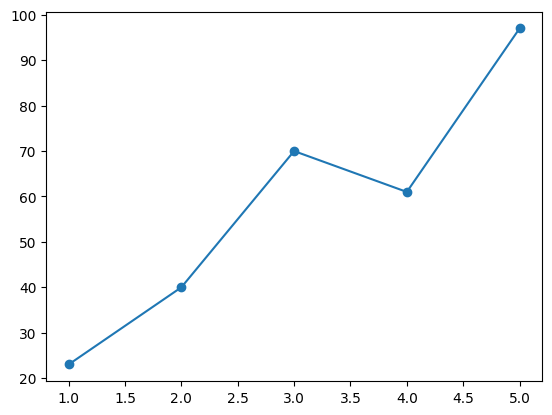

/tmp/ipython-input-1487147941.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


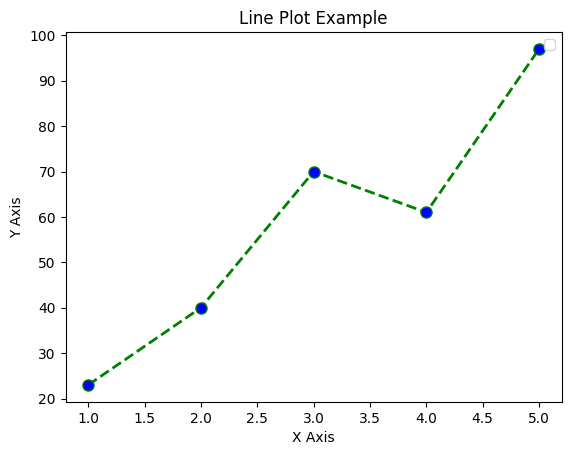

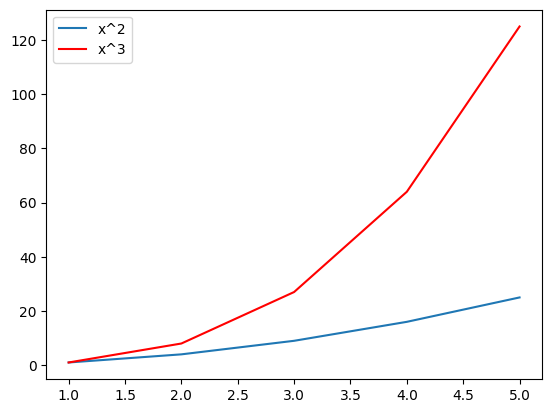

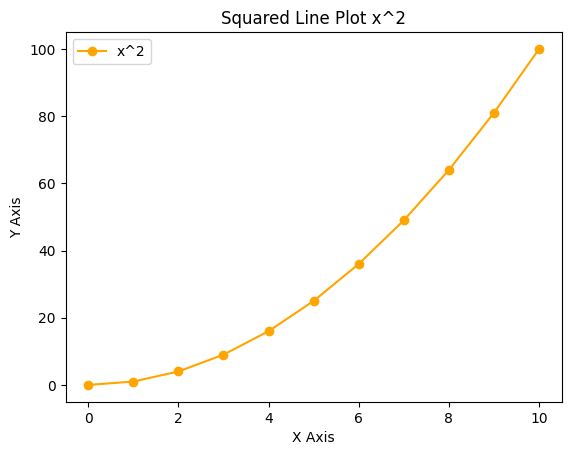

In [2]:
# TRENDS OVER TIME =  Line plot

#sample
x = [1, 2, 3, 4, 5]
y = [23, 40, 70, 61, 97]

#crear una figura
plt.figure()

#Plot comand
plt.plot(x, y, marker='o')

#show
plt.show()

# Personalización: color, estilo de línea, marcadores:
# Añadir títulos, etiquetas y leyendas:
plt.plot(x, y, color='green', linestyle='dashed', linewidth=2, marker='o', markerfacecolor='blue', markersize=8)
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Plot Example')
plt.legend()
plt.show()

# Múltiples líneas en un mismo gráfico:
y1 = [x_i**2 for x_i in x]
y2 = [x_i**3 for x_i in x]
plt.plot(x, y1, label='x^2')
plt.plot(x, y2, label='x^3', color='red')
plt.legend()
plt.show()

#excercise = line plot al cuadrado
x = list(range(0,11))
y3 = [i**2 for i in x]
plt.plot(x, y3,  marker='o', label='x^2', color='orange')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Squared Line Plot x^2')
plt.legend()
plt.show()


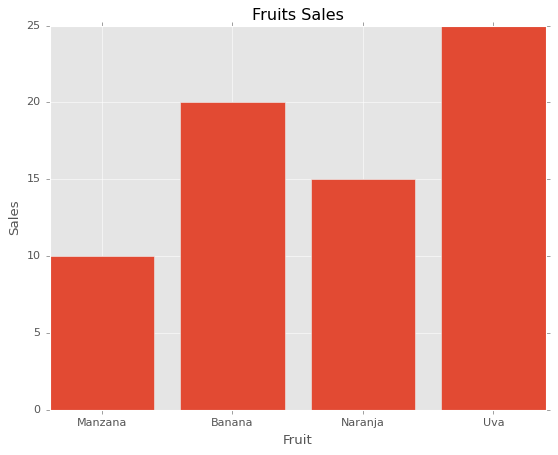

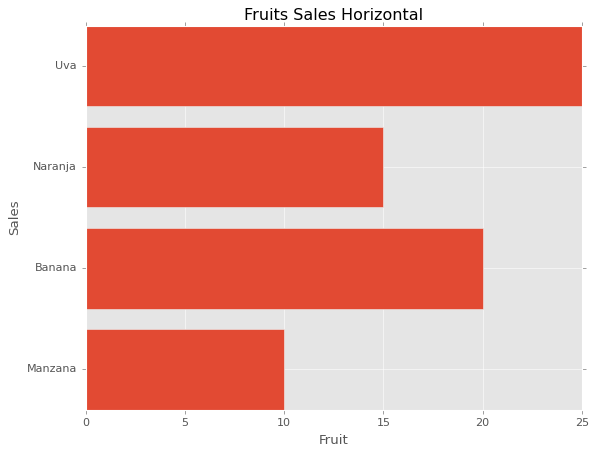

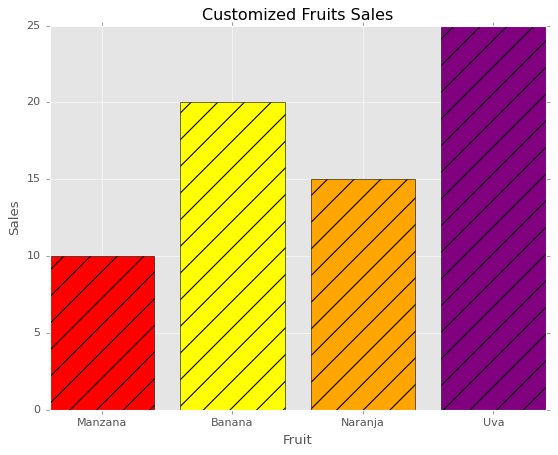

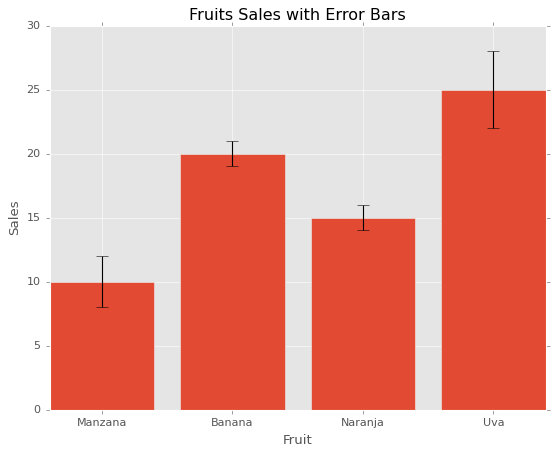

In [ ]:
# Gráficos de barras (Bar Charts)

#Vertical--> comparar categorías:

categories = ["Manzana", "Banana", "Naranja", "Uva"]
values = [10, 20, 15, 25]

plt.bar(categories, values)
plt.title('Fruits Sales')
plt.xlabel('Fruit')
plt.ylabel('Sales')
plt.show()

# Horizontal: útil con nombres largos:
plt.barh(categories, values)
plt.title('Fruits Sales Horizontal')
plt.xlabel('Fruit')
plt.ylabel('Sales')
plt.show()

#Personalización: colores, bordes, patrón:
plt.bar(categories, values, color=['red','yellow', 'orange', 'purple'], edgecolor='black', hatch='/')
plt.title('Customized Fruits Sales')
plt.xlabel('Fruit')
plt.ylabel('Sales')
plt.show()

# Añadir error bars para mostrar variabilidad:
import numpy as np

values = np.array(values)
std_dev = np.random.randint(1, 4, size=len(values))

plt.bar(categories, values, yerr=std_dev, capsize=5)
plt.title('Fruits Sales with Error Bars')
plt.xlabel('Fruit')
plt.ylabel('Sales')
plt.show()

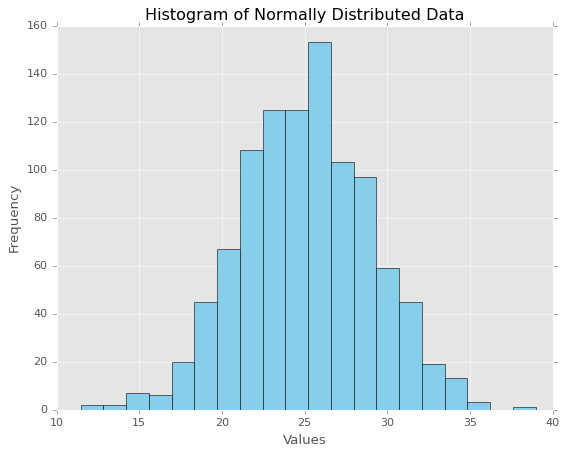

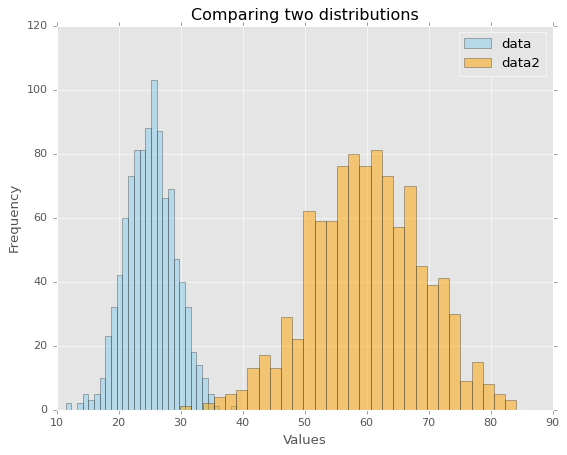

In [ ]:
# Histogramas

#sample
data = np.random.normal(25, 4, 1000) #(mean, standar deviation, n)

plt.hist(data, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Normally Distributed Data')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()


# Comparar distribuciones:
data2 = np.random.normal(60, 9, 1000) #(mean, standar deviation, n)
plt.hist(data, bins=30, alpha=0.5, label='data', color='skyblue', edgecolor='black')
plt.hist(data2, bins=30, alpha=0.5, label='data2',color='orange', edgecolor='black')
plt.title('Comparing two distributions')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()


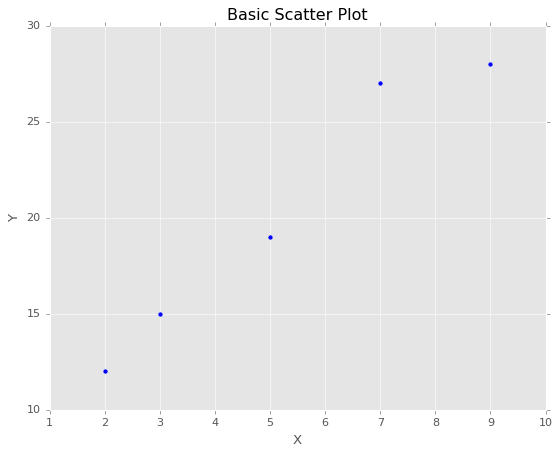

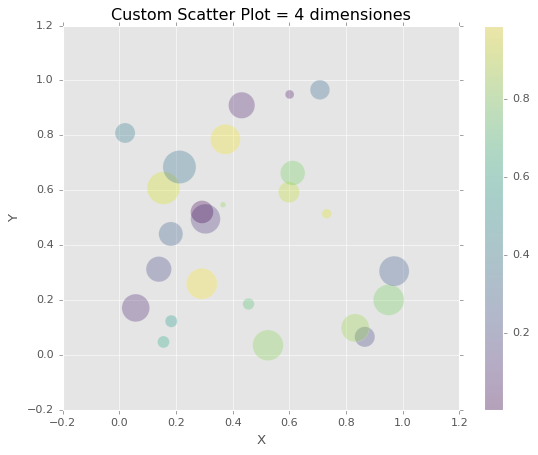

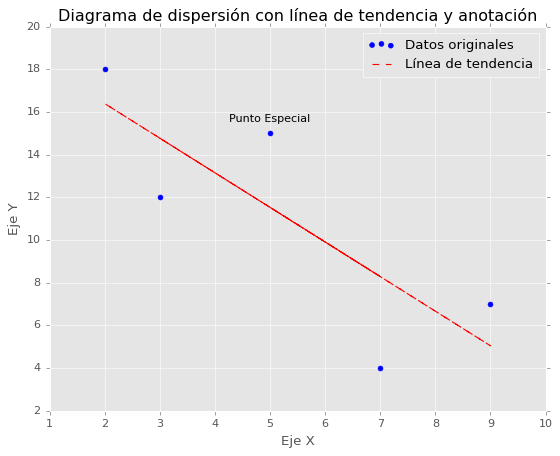

In [ ]:
# Gráficos de dispersión (Scatter Plots)

#sample
x = [2, 3, 5, 7, 9]
y = [12, 15, 19, 27, 28]

plt.scatter(x, y)
plt.title('Basic Scatter Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# Personalizar color, tamaño y transparencia:

np.random.seed(42)

x = np.random.rand(25)
y = np.random.rand(25)
colors = np.random.rand(25)
sizes = 1000 * np.random.rand(25)

plt.scatter(x, y, c=colors, s=sizes, alpha=0.3, cmap='viridis')

#scale legend
plt.colorbar()

plt.title('Custom Scatter Plot = 4 dimensiones')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


# Añadir línea de tendencia y anotaciones:

import matplotlib.pyplot as plt
import numpy as np

# Listas de ejemplo (pueden tener cualquier cantidad de elementos)
x = [3, 7, 2, 9, 5]
y = [12, 4, 18, 7, 15]

# === Línea de tendencia lineal ===
# Ajuste lineal de los datos (grado 1)
coeficientes = np.polyfit(x, y, 1)
tendencia = np.poly1d(coeficientes)

# Graficar los puntos
plt.scatter(x, y, label='Datos originales', color='blue')

# Graficar la línea de tendencia
plt.plot(x, tendencia(x), 'r--', label='Línea de tendencia')

# Agregar anotación en el último punto
plt.annotate(
    'Punto Especial',          # Texto de la anotación
    (x[-1], y[-1]),            # Último punto de la lista
    textcoords="offset points",
    xytext=(0,10),             # Desplazamiento del texto
    ha='center'
)

# Etiquetas y título
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Diagrama de dispersión con línea de tendencia y anotación')
plt.legend()
plt.show()


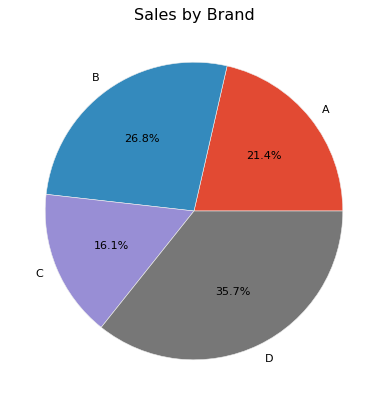

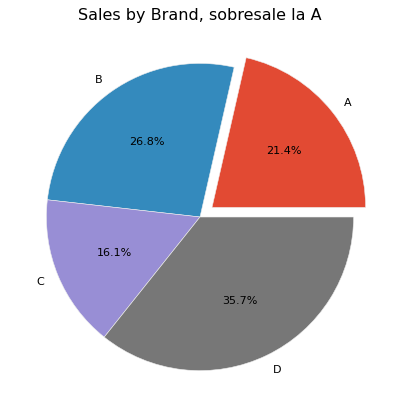

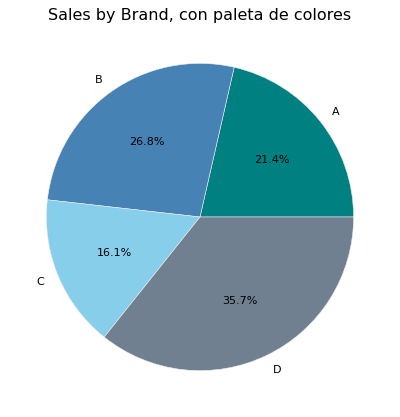

In [ ]:
#basic pie chart     plt.pie()

brands = ['A', 'B', 'C', 'D']
sales = [120, 150, 90, 200]

plt.figure(figsize=(6,6))
plt.pie(sales, labels=brands, autopct='%1.1f%%') #% con 1 punto decimal
plt.title('Sales by Brand')
plt.show()


#Personalización: explode para resaltar, colors para cambiar colores,
explode = (0.1, 0, 0, 0)  #sobresale la 1° slice
plt.pie(sales, labels=brands, autopct='%1.1f%%', explode = explode)    #explode resalta una sección.
plt.title('Sales by Brand, sobresale la A')
plt.show()

#cambiar los colores
colores = ['teal', 'steelblue', 'skyblue', 'slategray']
plt.pie(sales, labels=brands, autopct='%1.1f%%', colors= colores )
plt.title('Sales by Brand, con paleta de colores')
plt.show()

# plt.pie(sales, labels=brands, autopct='%1.1f%%',  shadow=True)  #shadow=True añade sombra.
# plt.title('Sales by Brand, con sombreado')
# plt.show()


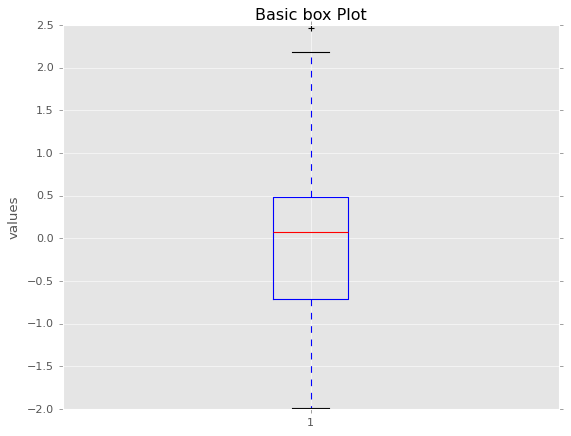

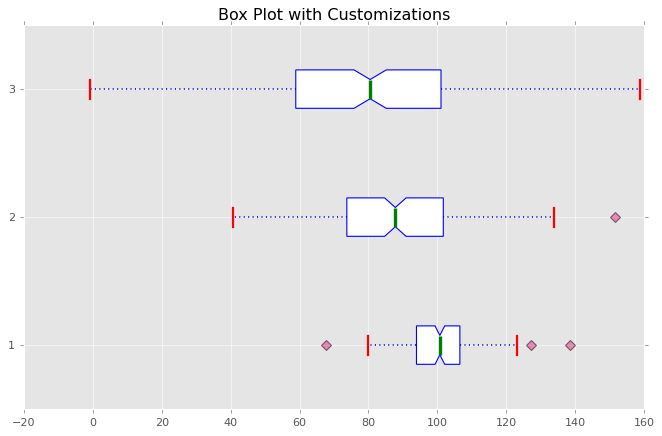

In [ ]:
from matplotlib.lines import lineStyles

# == crear boxplot ==   plt.boxplot()
# Muestra la distribución de datos:  Min, Q1, Mediana, Q3, Max + Outliers como puntos individuales

#sample
data = np.random.randn(100)  #datos aleatorios de una normal standarizada

plt.boxplot(data)
plt.title('Basic box Plot')
plt.ylabel('values')
plt.show()


# comparación de múltiples datasets en un mismo gráfico.

#3 datasetss diferentes
data1 = np.random.normal(100, 10, 200)
data2 = np.random.normal(90, 20, 200)
data3 = np.random.normal(80, 30, 200)

#combinados
data = [data1, data2, data3]

#crear figura de tamaño especifico
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111) #(1 fila 1 columna, primer grafico)

#box plots horizontales con optiones customizadas: colores, estilo de whiskers, caps, medianas y outliers.
bp = ax.boxplot(data,
                patch_artist=True,  #fil boxes with color
                notch=True,  #add notch to show confidence interval around the median --> una MUESCA
                vert=False)   #drow boxes horizontally

#customize whiskers
for whisker in bp['whiskers']:
  whisker.set(color='blue', linewidth=1.5, linestyle=":") #dashed blue whiskers


#customize caps (horizontal lines at the end of wiskers)
for cap in bp['caps']:
  cap.set(color='red', linewidth=2)

#customize medians (horizontal lines inside the box)
for median in bp['medians']:
  median.set(color='green', linewidth=3)

#customize outliers as individual points
for flier in bp['fliers']:
  flier.set(marker='D', color='#e7298a', alpha=0.5)   #en forma de diamante, color magenta

plt.title('Box Plot with Customizations')
plt.show()



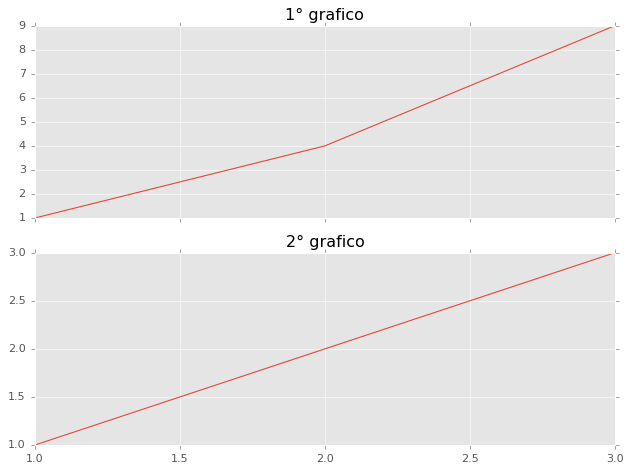

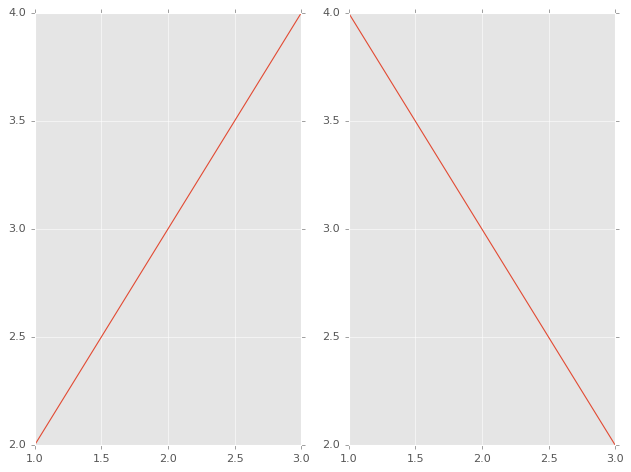

In [ ]:
#==subplot==    2 o + graficos juntos en una misma figura    plt.subplots()



# Figure → contenedor general del gráfico (la “ventana” o página).
# Axes → cada gráfico individual dentro de la Figure.

fig, (ax1, ax2) = plt.subplots(2, sharex=True)  #2 filas, 1 columna = vertically
                                                #sharex=True comparte eje x.
ax1.plot ([1,2,3],[1,4,9]) #una curva
ax1.set_title('1° grafico')

ax2.plot ([1,2,3],[1,2,3])  #una linea
ax2.set_title('2° grafico')

plt.tight_layout() #ajustar espacio para evitar overlap
plt.show()  #display


fig, [ax1, ax2] = plt.subplots(1,2) #1 fila, 2 columnas = horizontally

ax1.plot ([1,2,3],[2,3,4])
ax2.plot ([1,2,3],[4,3,2])
plt.tight_layout() #ajustar espacio para evitar overlap
plt.show()  #display




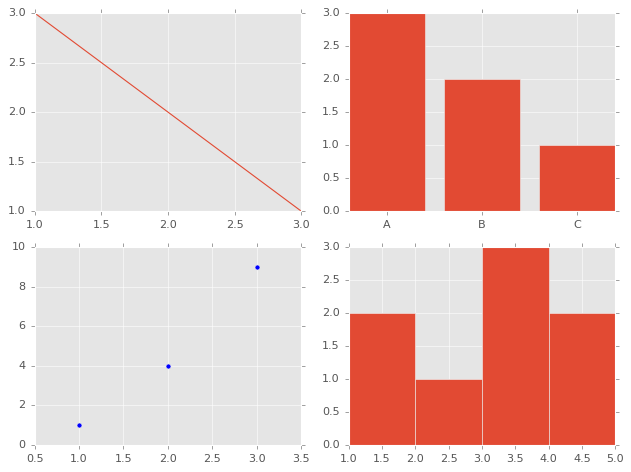

In [ ]:
#4 graficos juntos

fig, axs = plt.subplots(2,2) #2 filas, 2 columnas = 4

axs[0,0].plot ([1,2,3],[3,2,1])
axs[0,1].bar (['A', 'B', 'C'],[3,2,1])
axs[1,0].scatter ([1,2,3],[1,4,9])
axs[1,1].hist ([1,1,2,3,3,3,4,4], bins=[1,2,3,4,5])
plt.tight_layout() #ajustar espacio para evitar overlap
plt.show()  #display

#Opciones: compartir ejes (sharex, sharey), ajustar layout (plt.tight_layout()), combinar distintos tipos de gráficos.

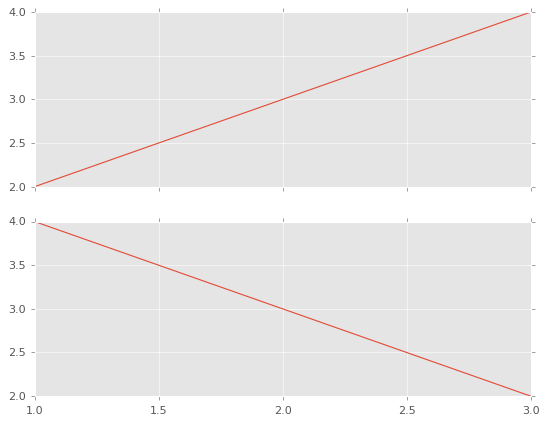

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot([1, 2, 3], [2, 3, 4])
ax2.plot([1, 2, 3], [4, 3, 2])

plt.show()

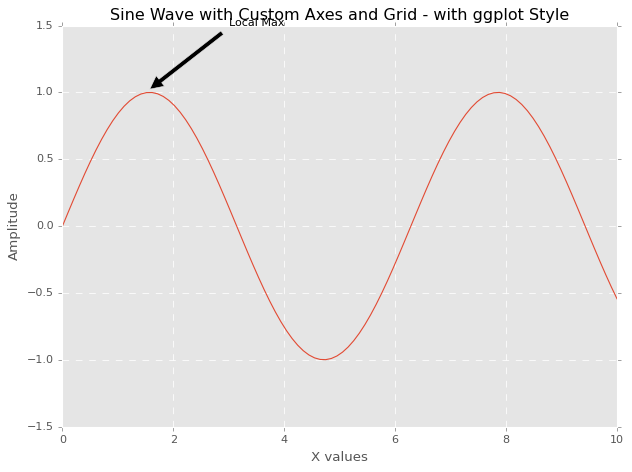

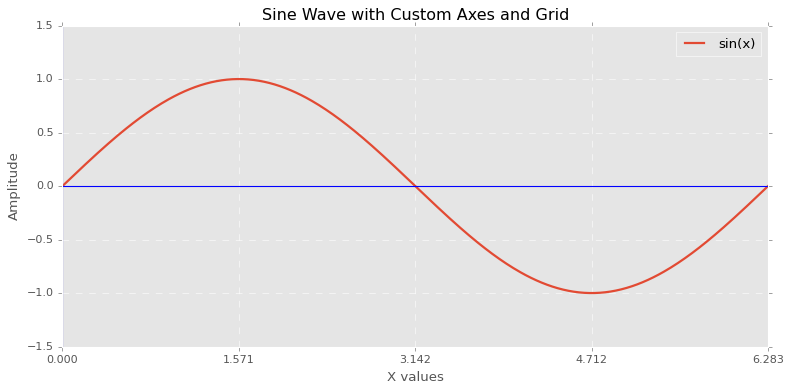

In [ ]:
# Avanzado

#customizar ejes y grid: ajustar límites, estilo de ticks, líneas de la cuadrícula.

import numpy as np
import matplotlib.pyplot as plt

# Datos
x = np.linspace(0, 10, 100) #100 datos equiespaciados entre 0 y 10
y = np.sin(x)  #funcion seno

plt.style.use('ggplot')  #Estilos y temas

plt.plot(x, y)

# Personalizar ejes
plt.xlim(0,10)
plt.ylim (-1.5, 1.5)

# Grid personalizado
plt.grid(True, which='both', linestyle='--', linewidth=0.7)

#ejes y titulos
plt.xlabel('X values')
plt.ylabel('Amplitude')
plt.title('Sine Wave with Custom Axes and Grid - with ggplot Style')

# para señalar puntos clave --> añade texto o flechas
plt.annotate('Local Max', xy=(1.5,1), xytext=(3,1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()


#con chatGPT

import numpy as np
import matplotlib.pyplot as plt

# Datos
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x)

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(10,5))

# Graficar seno
ax.plot(x, y, label='sin(x)', linewidth=2)

# Personalizar ejes
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-1.5, 1.5)
ax.set_xticks(np.arange(0, 2*np.pi + 0.1, np.pi/2))
ax.set_yticks(np.arange(-1.5, 1.6, 0.5))

ax.set_xlabel('X values')
ax.set_ylabel('Amplitude')
ax.set_title('Sine Wave with Custom Axes and Grid')

# Grid personalizado
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

# Línea horizontal y vertical en 0
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.legend()

plt.tight_layout()
plt.show()





---



#excercise = no estoy segura de los puntos 4 y 5

importar este conjunto de datos incluido en el sample_data de Google colab  "california_housing_test.csv"


import pandas as pd df = pd.read_csv('sample_data/california_housing_train.csv'

1. Mostrar las primeras 10 filas.
2. Mostrar todas las calles con una población mayor a 800 habitantes.
3. Graficar las poblaciones para mostrar la distribución de diferentes rangos de población.
4. Suponiendo que tener calles con pocas casas pero con precios altos es un problema para nuestro análisis, determine un método para eliminar dichas calles y elimínelas del conjunto de datos.
5. Graficar el valor medio de la vivienda de las calles restantes según la población.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load csv file
df = pd.read_csv('sample_data/california_housing_train.csv')

def initial_inspection(df):
    print("="*60)
    print("🔎 FIRST 10 ROWS")
    print("="*60)
    print(df.head(10))     # 1. Mostrar las primeras 10 filas.

    print("\n" + "="*60)
    print("📐 DATASET SHAPE")
    print("="*60)
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    print("\n" + "="*60)
    print("🧾 DATA INFO")
    print("="*60)
    print(df.info())

    print("\n" + "="*60)
    print("🔁 DUPLICATED ROWS")
    print("="*60)
    print(f"Duplicated rows: {df.duplicated().sum()}")

# Ejecutar inspección
initial_inspection(df)


🔎 FIRST 10 ROWS
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   
5    -114.58     33.63                29.0       1387.0           236.0   
6    -114.58     33.61                25.0       2907.0           680.0   
7    -114.59     34.83                41.0        812.0           168.0   
8    -114.59     33.61                34.0       4789.0          1175.0   
9    -114.60     34.83                46.0       1497.0           309.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0       

In [ ]:
#2. Mostrar todas las calles con una población mayor a 800 habitantes.

population_800 = df[df['population'] > 800]

percentage = len(population_800) / len(df) * 100

print("="*60)
print("POPULATION OVER 800")
print("="*60)
print (population_800)
print(f"Size is {len(population_800)} rows ({percentage:.1f}%)")


POPULATION OVER 800
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
6        -114.58     33.61                25.0       2907.0           680.0   
8        -114.59     33.61                34.0       4789.0          1175.0   
10       -114.60     33.62                16.0       3741.0           801.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population  households  

In [ ]:
# Columna de interés
data = df['population']

# Número de datos
N = len(data)
data_min, data_max = data.min(), data.max()

# --- 1️⃣ Regla de Sturges ---
bins_sturges = int(1 + np.log2(N))

# --- 2️⃣ Regla de Rice ---
bins_rice = int(2 * N**(1/3))

# --- 3️⃣ Regla de Scott ---
bin_width_scott = 3.5 * data.std() / N**(1/3)
bins_scott = int(np.ceil((data_max - data_min) / bin_width_scott))

# --- 4️⃣ Regla de Freedman-Diaconis ---
IQR = data.quantile(0.75) - data.quantile(0.25)
bin_width_fd = 2 * IQR / N**(1/3)
bins_fd = int(np.ceil((data_max - data_min) / bin_width_fd))

#cantidad ideal de bins
print(f"Sturges: {bins_sturges} bins")
print(f"Rice: {bins_rice} bins")
print(f"Scott: {bins_scott} bins")
print(f"Freedman-Diaconis: {bins_fd} bins")


Sturges: 15 bins
Rice: 51 bins
Scott: 229 bins
Freedman-Diaconis: 493 bins


Distribution of Population


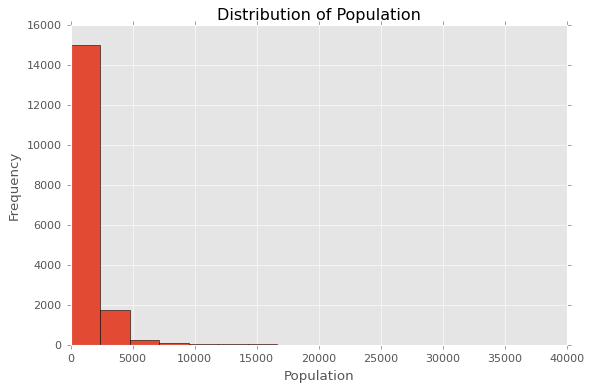

In [ ]:
# 3. Graficar las poblaciones para mostrar la distribución de diferentes rangos de población.
print("="*60)
print("Distribution of Population")
print("="*60)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['population'], bins=15, edgecolor='black')
plt.title('Distribution of Population')
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



Descriptive statistics:
         households  median_house_value
count  17000.000000        17000.000000
mean     501.221941       207300.912353
std      384.520841       115983.764387
min        1.000000        14999.000000
25%      282.000000       119400.000000
50%      409.000000       180400.000000
75%      605.250000       265000.000000
max     6082.000000       500001.000000


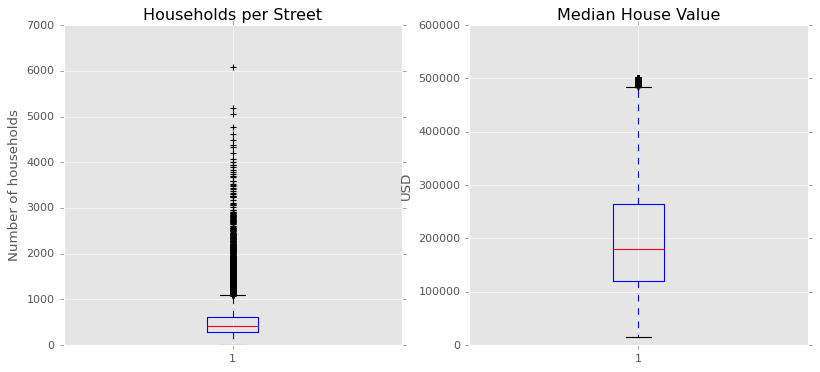

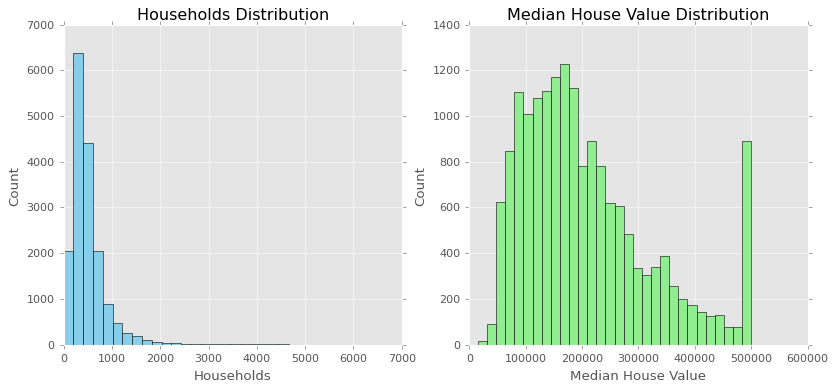

In [ ]:
# Estadística descriptiva de las variables clave
print("\nDescriptive statistics:")
print(df[['households', 'median_house_value']].describe())

# Boxplots de las variables
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df['households'])
plt.title('Households per Street')
plt.ylabel('Number of households')

plt.subplot(1,2,2)
plt.boxplot(df['median_house_value'])
plt.title('Median House Value')
plt.ylabel('USD')

plt.show()

# Histogramas para ver distribución
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['households'], bins=30, color='skyblue', edgecolor='black')
plt.title('Households Distribution')
plt.xlabel('Households')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.hist(df['median_house_value'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Median House Value Distribution')
plt.xlabel('Median House Value')
plt.ylabel('Count')

plt.show()


In [ ]:
# Calcular IQR
Q1_value = df['median_house_value'].quantile(0.25)
Q3_value = df['median_house_value'].quantile(0.75)
IQR_value = Q3_value - Q1_value

# Definir límites para considerar outliers
lower_value = Q1_value - 1.5 * IQR_value
upper_value = Q3_value + 1.5 * IQR_value

# Filas que son outliers
print(f"Outliers in median_house_value: {len(outliers_value)} rows")


Outliers in median_house_value: 895 rows


In [ ]:
# Valores outliers para 'median_house_value'
outliers_value_values = df.loc[(df['median_house_value'] < lower_value) | (df['median_house_value'] > upper_value), 'median_house_value']
print("\nOutliers in 'median_house_value':")
print(outliers_value_values.sort_values())


Outliers in 'median_house_value':
8560     483500.0
7765     483600.0
5703     483700.0
2493     484100.0
16180    484600.0
           ...   
16421    500001.0
16434    500001.0
260      500001.0
16512    500001.0
215      500001.0
Name: median_house_value, Length: 895, dtype: float64


In [ ]:
#los outliers son las casas que valen mas de $483.500

value = 483500

import numpy as np
percentile = np.sum(df['median_house_value'] <= value) / len(df) * 100
print(f"El valor ${value} está en el percentil: {percentile:.2f}%")

El valor $483500 está en el percentil: 94.74%


In [ ]:
#Todas las cass con valor "alto" tiene tranvsersalidad en la cantidad de hogares [de 0 a 2000], no veo una relación alli.
#el problema es el valor alto alto de las casas, no que haya hogares que representen pocas casas...

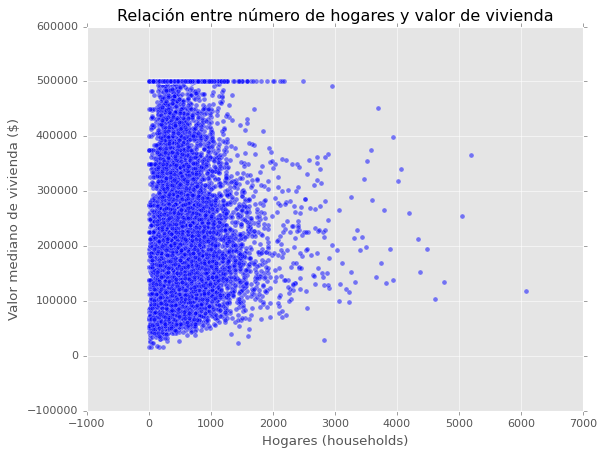

In [ ]:
# Scatter plot básico
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='households',
    y='median_house_value',
    alpha=0.5,          # transparencia para ver densidad
    color='blue'
)
plt.title("Relación entre número de hogares y valor de vivienda")
plt.xlabel("Hogares (households)")
plt.ylabel("Valor mediano de vivienda ($)")
plt.show()

In [ ]:
percentil_5 = df['households'].quantile(0.05)
print(f"El valor de households en el percentil 5% es: {percentil_5:.2f}")


El valor de households en el percentil 5% es: 126.00


In [ ]:
#Relacion entre:  calles con pocas casas pero con precios altos

# 1️⃣ Definir umbrales usando percentiles
low_households = df['households'].quantile(0.05)    # 5# inferior → pocas casas
high_price = df['median_house_value'].quantile(0.9474) # 94,74% superior → precios altos

print(f"Umbral casas bajas: {low_households:.0f}")
print(f"Umbral precio alto: {high_price:.0f}")

# 2️⃣ Crear columna booleana que identifique estas calles
df['few_houses_high_price'] = (df['households'] <= low_households) & \
                              (df['median_house_value'] >= high_price)

# 3️⃣ Ver cuántas calles cumplen la condición
print("Cantidad de calles con pocas casas y precio alto:", df['few_houses_high_price'].sum())



Umbral casas bajas: 126
Umbral precio alto: 483471
Cantidad de calles con pocas casas y precio alto: 64


In [ ]:
# Crear nuevo dataset excluyendo calles con pocas casas y precio alto
df_filtered = df[~df['few_houses_high_price']].copy()

# Verificar tamaño
print(f"Tamaño original: {len(df)}, tamaño filtrado: {len(df_filtered)}")


Tamaño original: 17000, tamaño filtrado: 16936


In [ ]:
print(df_filtered)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population  households  median_income  media

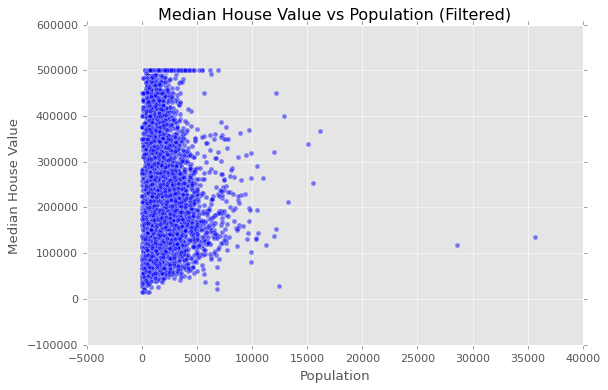

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df_filtered['population'],
            df_filtered['median_house_value'],
            alpha=0.5)

plt.title('Median House Value vs Population (Filtered)')
plt.xlabel('Population')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()




---



Anscombe’s Quartet, data set famoso que demuestra que:

📊 Nunca confíes solo en estadísticas resumen. Siempre visualiza los datos.

Los cuatro conjuntos tienen estadísticas idénticas, pero:

Uno es lineal normal.

Otro es curvo (no lineal).

Otro tiene un outlier que cambia la pendiente.

Otro tiene un punto extremo que domina la correlación.

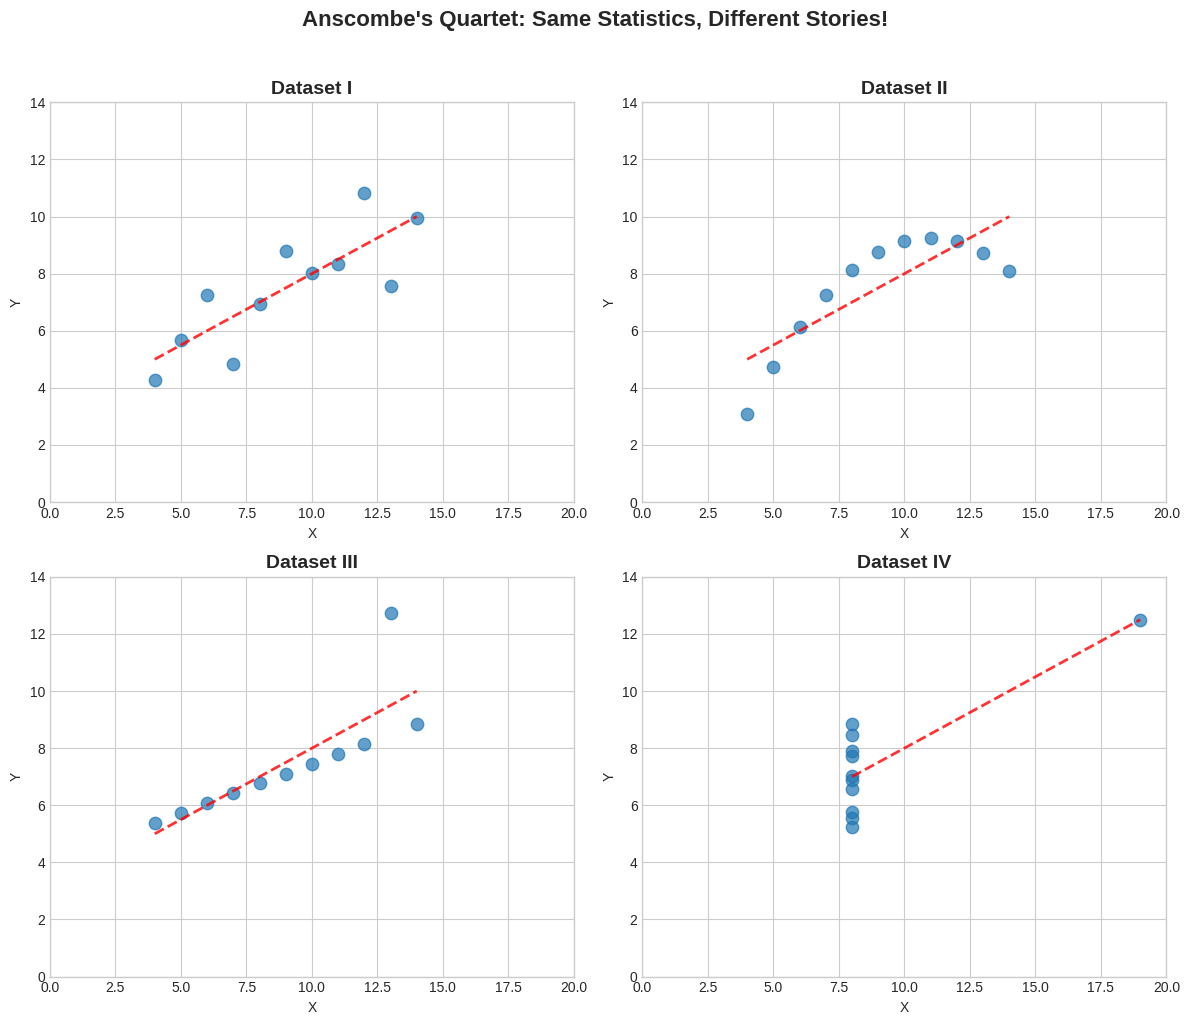



---



## The Purpose of Different Chart Types
    +---------------------------------------------------------------------+
    |                                                                     |
    |   LINE CHART                                                        |
    |   ----------                                                        |
    |   Purpose: Show TRENDS over time                                    |
    |   Use when: Data changes over a sequence (time, order)              |
    |   Example: Temperature over a week, stock prices over a year        |
    |                                                                     |
    |   BAR CHART                                                         |
    |   ---------                                                         |
    |   Purpose: COMPARE categories                                       |
    |   Use when: Comparing distinct groups                               |
    |   Example: Sales by region, grades by subject                       |
    |                                                                     |
    |   HISTOGRAM                                                         |
    |   ---------                                                         |
    |   Purpose: Show DISTRIBUTION of one variable                        |
    |   Use when: Understanding how values are spread out                 |
    |   Example: Age distribution, test score distribution                |
    |                                                                     |
    |   SCATTER PLOT                                                      |
    |   ------------                                                      |
    |   Purpose: Show RELATIONSHIP between two variables                  |
    |   Use when: Exploring correlations or patterns                      |
    |   Example: Height vs weight, study time vs grades                   |
    |                                                                     |
    |   BOX PLOT                                                          |
    |   --------                                                          |
    |   Purpose: Compare DISTRIBUTIONS across groups                      |
    |   Use when: Comparing spread and outliers across categories         |
    |   Example: Salary by department, scores by class                    |
    |                                                                     |
    +---------------------------------------------------------------------+


1️⃣ Matplotlib  →  📈 Control fino

📌 La base de todo. Es la librería más tradicional.

Control total sobre gráficos.

Ideal para gráficos simples y personalizables.

Base sobre la que trabajan otras librerías.




2️⃣ Seaborn  → 📊 EDA

📌 Estadística con estética automática.

Construida sobre Matplotlib.

Mucho más linda “de fábrica”.

Excelente para análisis exploratorio (EDA).

Facilita gráficos estadísticos: boxplot, violinplot, heatmaps, etc.

👉 Perfecta cuando estás analizando datasets tipo Kaggle.


In [ ]:
# # ============================================
# # RUN THIS CELL FIRST - All imports for today
# # ============================================
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats

# # Display settings
# plt.style.use('seaborn-v0_8-whitegrid')
# %matplotlib inline
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_columns', 20)

# # Set default figure size
# plt.rcParams['figure.figsize'] = (10, 6)

# print("All libraries loaded! Ready for visualization.")

In [ ]:
# ===========================================
# Basic Line Plot
# ===========================================
#   - plt.plot(x_data, y_data, marker='o') )
#   - plt.title('...')
#   - plt.xlabel('...')
#   - plt.ylabel('...')
#   - plt.show()

In [ ]:
# ===========================================
# # Customized Line Plot - Professional Quality
# ===========================================
# plt.figure(figsize=(10, 6))

# plt.plot(days, temperatures,
#          marker='o',           # Add points at each value
#          linewidth=2,          # Thicker line
#          markersize=8,         # Bigger points
#          color='steelblue')    # Professional color

# plt.title('Temperature Variation Over a Week', fontsize=16, fontweight='bold')
# plt.xlabel('Day', fontsize=12)
# plt.ylabel('Temperature (F)', fontsize=12)
# plt.grid(True, alpha=0.3)  # Subtle gridlines
# plt.ylim(68, 85)  # Set Y-axis range to emphasize variation

# plt.show()

# print("Same data, much more professional!")

In [ ]:
# ===========================================
#  Basic Bar Chart
# ===========================================
# Create a bar chart with:
#   - plt.bar(categories, values)
#   - plt.title('...')
#   - plt.xlabel('...')
#   - plt.ylabel('...')
#   - plt.show()

In [ ]:
# # Customized Bar Chart - Presentation Ready
# plt.figure(figsize=(10, 6))

# bars = plt.bar(months, sales,
#                color='coral',         # Nice color
#                edgecolor='black',     # Border around bars
#                linewidth=1.2)

# plt.title('Monthly Sales Report', fontsize=16, fontweight='bold')
# plt.xlabel('Month', fontsize=12)
# plt.ylabel('Sales Amount ($)', fontsize=12)
# plt.xticks(rotation=45, ha='right')  # Rotate labels if needed

# # Add value labels on top of each bar
# for bar, value in zip(bars, sales):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
#              f'${value:,}', ha='center', va='bottom', fontsize=10)

# plt.tight_layout()  # Prevent labels from being cut off
# plt.show()

In [ ]:
# # Creating subplots - multiple charts in one figure - this is how dashboards are built!

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# # Left plot: Line chart (temperatures)
# axes[0].plot(days, temperatures, marker='o', linewidth=2, color='steelblue')
# axes[0].set_title('Weekly Temperature', fontsize=14, fontweight='bold')
# axes[0].set_xlabel('Day')
# axes[0].set_ylabel('Temperature (F)')
# axes[0].grid(True, alpha=0.3)

# # Right plot: Bar chart (sales)
# axes[1].bar(months, sales, color='coral', edgecolor='black')
# axes[1].set_title('Monthly Sales', fontsize=14, fontweight='bold')
# axes[1].set_xlabel('Month')
# axes[1].set_ylabel('Sales ($)')
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()  # Adjust spacing
# plt.show()


a partir de aca empezó a usar libreria Seaborn .sns

In [ ]:
# # ===========================================
# #  Basic Seaborn barplot
# # ===========================================

# # Seaborn barplot - shows mean with confidence interval  = con intervalos de confianza para el estimador --> si lo haces con plt, tiene otra sintaxis
#sns.barplot(data=df, x='cat', y='val')  # Seaborn (with CI)

# plt.figure(figsize=(10, 6))

# sns.barplot(data=tips, x='day', y='tip', palette='viridis')

# plt.title('Average Tip by Day of Week', fontsize=16, fontweight='bold')
# plt.xlabel('Day', fontsize=12)
# plt.ylabel('Average Tip ($)', fontsize=12)
# plt.show()

# print("Bar height = mean, black line = 95% confidence interval")
# print("Sunday has highest mean but widest CI (more uncertainty).")

In [ ]:
# # Grouped bar plot with hue - compare across two dimensions  activa el hue segun sexo + IC
# plt.figure(figsize=(12, 6))

# sns.barplot(data=tips, x='day', y='tip', hue='sex', palette='Set2')

# plt.title('Average Tip by Day and Gender', fontsize=16, fontweight='bold')
# plt.xlabel('Day', fontsize=12)
# plt.ylabel('Average Tip ($)', fontsize=12)
# plt.legend(title='Gender')
# plt.show()

# print("Grouped bars allow comparison across multiple dimensions.")

In [ ]:
# Count plot - counts occurrences in each category    hace el recuento
# plt.figure(figsize=(10, 6))

# sns.countplot(data=tips, x='day', hue='time', palette='coolwarm')

# plt.title('Number of Transactions by Day and Time', fontsize=16, fontweight='bold')
# plt.xlabel('Day', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.show()

# print("Weekend = dinner only, weekdays = mostly lunch.")
# print("This tells us about the waiter's work schedule!")

In [ ]:
# # ===========================================
# #  Basic Seaborn Histogram -  DISTRIBUTION OF ONE VARIABLE
# # ===========================================
# # Create a histogram with:
# #   - plt.figure(figsize=(10, 6))
# #   - sns.histplot(data=tips, x='total_bill', bins=20)
# #   - plt.title('...')
# #   - plt.show()
# plt.figure(figsize=(10,6))

# sns.histplot(data=tips, x='total_bill', bins=20, color='steelblue')

# plt.title("Distribution of Total Bill", fontsize=16, fontweight='bold')
# plt.xlabel('Total Bill ($)', fontsize=12)
# plt.ylabel('Frequency', fontsize=12)

# plt.show()

In [ ]:
# # Histogram with KDE (density curve)   kde=True

# plt.figure(figsize=(10, 6))

# sns.histplot(data=tips, x='total_bill', bins=20, kde=True, color='coral')

# plt.title('Distribution of Total Bill (with KDE)', fontsize=16, fontweight='bold')
# plt.xlabel('Total Bill ($)', fontsize=12)
# plt.ylabel('Frequency', fontsize=12)
# plt.show()

# print("KDE (smooth curve) shows the underlying distribution shape")
# print("Notice the right skew - a long tail of expensive meals.")

# 👉 kde=True    dibuje una curva suave que representa la distribución estimada de los datos.

In [ ]:
# ===========================================
#  Histogram with hue
# ===========================================
# Add hue to compare Lunch vs Dinner:  concviene mas las cuentas de dinner!

# plt.figure(figsize=(10, 6))
# sns.histplot(data=tips, x='total_bill', hue='time', bins=20, alpha=0.6)
# plt.title('Bill Distribution: Lunch vs Dinner')
# plt.xlabel('Total Bill ($)')
# plt.ylabel('Frequency')
# plt.show()


In [ ]:
# grafico de asociacion   - RELATIONSHIP BETWEEN TWO VARIABLES
sns.scatterplot(data=df, x='col1', y='col2', hue='category')
sns.regplot(data=df, x='col1', y='col2')  # With regression line

# ===========================================
# Basic Scatter Plot
# ===========================================
# Create a scatter plot with:

# plt.figure(figsize=(10, 6))

# sns.scatterplot(data=tips, x='total_bill', y='tip')
# plt.title("Total Bill vs Tip", fontsize=16, fontweight='bold')
# plt.xlabel("Total Bill ($)", fontsize=12)
# plt.ylabel("Tip ($)", fontsize=12)
# plt.show()

In [ ]:
# scatter plot + 2 dimensiones adicionales. A lo anterior, le suma hue y size
# ===========================================
#  Bubble Chart
# ===========================================
# Scatter plot with hue and size - FOUR dimensions!
# plt.figure(figsize=(12, 7))

# sns.scatterplot(data=tips, x='total_bill', y='tip',
#                 hue='time',           # Color by lunch/dinner
#                 size='size',          # Point size by party size
#                 sizes=(50, 300),      # Size range
#                 alpha=0.7)            # Transparency

# plt.title('Tips Analysis: Bill, Tip, Time, and Party Size', fontsize=16, fontweight='bold')
# plt.xlabel('Total Bill ($)', fontsize=12)
# plt.ylabel('Tip ($)', fontsize=12)
# plt.show()

# print("Four dimensions of data in one plot!")
# print("  X = Total Bill, Y = Tip, Color = Time, Size = Party Size")

In [ ]:
# estima la recta de regresion y la estimacion de la correlacion    #sns.regplot
# # Regression plot with trend line and statistics

# plt.figure(figsize=(10, 6))

# sns.regplot(data=tips, x='total_bill', y='tip',
#             scatter_kws={'alpha': 0.5},
#             line_kws={'color': 'red'})

# # Calculate and display correlation
# r, p = stats.pearsonr(tips['total_bill'], tips['tip'])
# plt.text(0.05, 0.95, f'r = {r:.3f}\np < 0.001',
#          transform=plt.gca().transAxes,
#          fontsize=12, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# plt.title('Total Bill vs Tip (with Regression)', fontsize=16, fontweight='bold')
# plt.xlabel('Total Bill ($)', fontsize=12)
# plt.ylabel('Tip ($)', fontsize=12)
# plt.show()

# print(f"Correlation: r = {r:.3f} (moderate-strong positive)")
# print(f"P-value: {p:.2e} (highly significant - not due to chance)")

Visualiza relación entre cuenta total y propina.

Ajusta una recta de regresión.

Calcula fuerza de relación (r).

Evalúa si es significativa (p-value).

Conclusión típica para tips:
👉 A mayor cuenta, mayor propina.
👉 Correlación positiva moderada-fuerte.
👉 No es azar (p muy bajo).

In [ ]:
# ===========================================
#  Basic Box Plot
#  COMPARING DISTRIBUTIONS ACROSS GROUPS
# ===========================================
# Create a box plot with:
# plt.figure(figsize=(10, 6))

# sns.boxplot(data=tips, x='day', y='total_bill')

# plt.title('Total Bill Distribution by Day')
# plt.xlabel('Day')
# plt.ylabel('Total Bill ($)')
# plt.show()

In [ ]:
# # Box plot with hue - comparing sub-groups segun almuerzo/cena [hue]
# plt.figure(figsize=(12, 6))

# sns.boxplot(data=tips, x='day', y='total_bill', hue='time', palette='Set2')

# plt.title('Total Bill: Day and Time Comparison', fontsize=16, fontweight='bold')
# plt.xlabel('Day', fontsize=12)
# plt.ylabel('Total Bill ($)', fontsize=12)
# plt.legend(title='Time')
# plt.show()

# print("Dinner bills are consistently higher than lunch bills.")
# print("Weekend dinner bills have the most variation.")

In [ ]:
#otro ejemplo de boxplot
# Compare score distributions with box plot
# plt.figure(figsize=(10, 6))

# sns.boxplot(data=scores_melted, x='Score Type', y='Score', palette='pastel')

# plt.title('Critic vs Audience Scores', fontsize=16, fontweight='bold')
# plt.xlabel('Score Type', fontsize=12)
# plt.ylabel('Score', fontsize=12)
# plt.show()

# print("Critics score slightly higher on average.")
# print("Audiences have more variability (wider box and whiskers).")

In [ ]:
#Advanced Visualizations: Pair Plots and Heatmaps

# Pair plot - many relationships at once
#sns.pairplot(df, hue='category')

#en la diagonal principal son histogramas, en el resto son graficos de correlacion (scatterplot). En punto de colores (leyenda)
#va alguna cariable categorica

# mpg_subset = mpg[['mpg', 'horsepower', 'weight', 'acceleration', 'origin']].dropna()

# sns.pairplot(mpg_subset, hue='origin', diag_kind='hist', height=2.5)

# plt.suptitle('MPG Dataset: Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')
# plt.show()

# print("Pair plot shows ALL relationships at once!")
# print("  Colors = origin (USA, Japan, Europe)")



In [ ]:
# MULTIPLE PLOTS IN ONE FIGURE (uso en dashboards)

fig, axes = plt.subplots(nrows, ncols, figsize=(w, h))
axes[row, col].plot(...)  # Access each subplot
plt.tight_layout()  # Prevent overlap

# SAVING FIGURES
plt.savefig('filename.png', dpi=300, bbox_inches='tight')

# Show
plt.show()

In [ ]:
# # correlation matrix
# numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
# corr_matrix = mpg[numeric_cols].corr()

# print("Correlation Matrix (raw numbers):")
# corr_matrix.round(2)

# el siguiente paso es graficarlo....

# # ===========================================
# #  Heatmap =  (mapa de calor)
# # ===========================================
# muestra valores numéricos usando colores.
# Más intenso / más oscuro → valor más alto
# Más claro → valor más bajo
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

#nos sirve al momento de elegir visualmente las variables numericas para armar el modelo machine learning....

# plt.figure(figsize=(10, 8))

# sns.heatmap(corr_matrix,
#              annot=True, # Show numbers
#              cmap='coolwarm', # Red-white-blue color scheme
#              center=0, # White at 0
#              square=True, # Squaare cells
#              linewidths=1 # Cell borders
#             )

# plt.title("Correlation Heatmap: MPG Dataset", fontsize=16, fontweight='bold')
# plt.tight_layout()

# plt.savefig('filename.png', dpi=300, bbox_inches='tight') -->  .png del grafico (se guarda en el server, de alli lo descargas )  Antes de show!

      #   'filename.png' - High quality PNG image
      #   'filename.pdf' - Vector PDF (best for print)
      #   'filename.svg' - Vector SVG (web/edit)
      #   dpi=300 - Resolution (300 is publication quality)
      #   bbox_inches='tight' - Prevents labels from being cut off

# plt.show()


In [ ]:
# BONUS: Visualizing Binary/Categorical outcomes in Scatter Plots
#Sometimes you want to visualize a numeric variable against a Yes/No outcome.

# Example: Does smoker status relate to tip amount?

# plt.figure(figsize=(10, 6))

# # stripplot shows individual points with jitter (prevents overlap)
# sns.stripplot(data=tips, x='smoker', y='tip', alpha=0.7, jitter=True)

# plt.title('Tips by Smoker Status', fontsize=16, fontweight='bold')
# plt.xlabel('Smoker', fontsize=12)
# plt.ylabel('Tip ($)', fontsize=12)
# plt.show()

# print("stripplot() shows individual points - good for categorical vs numeric.")
# print("Each point is one transaction. Jitter prevents overlap.")